# WattWise — Heuristic (Genetic Algorithm) for Battery Dispatch

Minimize the daily electricity bill by scheduling battery charging and discharging
in each 30-minute slot under CEB's Time-of-Use tariff.

**Method:** Genetic Algorithm (heuristic) — compared with the DP (exact method).

---
> **Shared code.** The data loader, battery parameters and `simulate()` now live in
> `src/model.py`, and the GA (`fitness`, `greedy_schedule`, `run_ga`) in
> `src/heuristic_solver.py`. The DP (`src/dp_solver.py`) imports the same model, so both
> methods optimise and are scored by exactly the same objective. The cells below import
> them; `inspect.getsource` prints the code where it used to be defined.


## Stage 1 — Data Loading

Load the cleaned 30-minute profiles into separate per-day arrays for solar, demand, and price.

### 1.1 Imports and data-loading functions

In [6]:
# import necessary libraries
import sys
import inspect
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("src").resolve()))  # run from the repo root

In [7]:
# Data loading is shared with the DP: src/model.py
from model import DATA_PATH, SLOTS_PER_DAY, SLOT_HOURS, load_profiles, list_days, get_day

print(inspect.getsource(get_day))

def get_day(df, date):
    """One day as 48-element arrays: solar, demand, price (plus labels)."""
    d = df[df["date"] == date].sort_values("slot_start").reset_index(drop=True)
    if len(d) != SLOTS_PER_DAY:
        raise ValueError(f"{date}: expected {SLOTS_PER_DAY} slots, got {len(d)}")
    return {
        "date": date,
        "solar": d["production_kWh"].to_numpy(float),
        "demand": d["consumption_kWh"].to_numpy(float),
        "price": d["price_LKR_per_kWh"].to_numpy(float),
        "band": d["band"].to_numpy(),
        "slot": d["slot_start"].to_numpy(),
    }



### 1.2 Sanity check — load one day and inspect it

In [8]:
# sanity check
df = load_profiles()
print("Days available:", list_days(df))

day = get_day(df, "2026-09-11")
print(f"\nLoaded {day['date']}")
print(f"  slots       : {len(day['solar'])}")
print(f"  total solar : {day['solar'].sum():.2f} kWh")
print(f"  total demand: {day['demand'].sum():.2f} kWh")
print(f"  price levels: {sorted(set(day['price']))} Rs/kWh")

Days available: ['2026-09-10', '2026-09-11', '2026-09-13', '2026-09-16', '2026-09-17']

Loaded 2026-09-11
  slots       : 48
  total solar : 14.07 kWh
  total demand: 9.58 kWh
  price levels: [np.float64(33.0), np.float64(47.0), np.float64(106.0)] Rs/kWh


### 1.3 Inspect slots, bands and prices
See how the 48 slots map to tariff bands and prices, and where the bands switch.

In [9]:
day = get_day(df, "2026-09-11")

# full 48-slot table: index, time, band, price
print("idx  time    band       price")
print("-" * 34)
for i in range(SLOTS_PER_DAY):
    print(f"{i:>3}  {day['slot'][i]:>5}   {day['band'][i]:<9}  {day['price'][i]:>5.0f}")

# where do the bands change? (should land on 05:30, 18:30, 22:30)
print("\nBand transitions:")
prev = None
for i in range(SLOTS_PER_DAY):
    if day["band"][i] != prev:
        print(f"  slot {i:>2} ({day['slot'][i]}) -> {day['band'][i]} (Rs {day['price'][i]:.0f})")
        prev = day["band"][i]

# how many slots in each band
print("\nSlots per band:")
bands, counts = np.unique(day["band"], return_counts=True)
for b, n in zip(bands, counts):
    print(f"  {b:<9}: {n} slots")

idx  time    band       price
----------------------------------
  0  00:00   Off-Peak      33
  1  00:30   Off-Peak      33
  2  01:00   Off-Peak      33
  3  01:30   Off-Peak      33
  4  02:00   Off-Peak      33
  5  02:30   Off-Peak      33
  6  03:00   Off-Peak      33
  7  03:30   Off-Peak      33
  8  04:00   Off-Peak      33
  9  04:30   Off-Peak      33
 10  05:00   Off-Peak      33
 11  05:30   Day           47
 12  06:00   Day           47
 13  06:30   Day           47
 14  07:00   Day           47
 15  07:30   Day           47
 16  08:00   Day           47
 17  08:30   Day           47
 18  09:00   Day           47
 19  09:30   Day           47
 20  10:00   Day           47
 21  10:30   Day           47
 22  11:00   Day           47
 23  11:30   Day           47
 24  12:00   Day           47
 25  12:30   Day           47
 26  13:00   Day           47
 27  13:30   Day           47
 28  14:00   Day           47
 29  14:30   Day           47
 30  15:00   Day           47
 31  

---

## Stage 2 — Battery Simulation & Bill Calculation

This is the core of the project: a function that takes a battery schedule (48 actions) and a battery size, simulates the battery throughout the day, and returns the electricity bill. This bill **is the objective function** that the GA will minimize.

**Sign convention:** positive action = discharge, negative = charge.


### 2.1 Battery constants (shared with the DP — keep identical)

In [10]:
# Battery model parameters, shared with the DP: src/model.py
from model import (CAPACITIES, SOC_RESERVE_FRAC, CHARGE_RATE_KW, DISCHARGE_RATE_KW,
                   MAX_CHARGE_KWH, MAX_DISCHARGE_KWH, ETA_C, ETA_D)
from heuristic_solver import PENALTY

print(f"reserve {SOC_RESERVE_FRAC}, charge <= {MAX_CHARGE_KWH} kWh/slot, "
      f"discharge <= {MAX_DISCHARGE_KWH} kWh/slot, eta_c = eta_d = {ETA_C} "
      f"(calibrated from the logs, scripts/calibrate_eta.py), penalty {PENALTY:g}")

reserve 0.2, charge <= 1.1 kWh/slot, discharge <= 1.25 kWh/slot, eta_c = eta_d = 0.91 (calibrated from the logs, scripts/calibrate_eta.py), penalty 100000


### 2.2 The simulation + bill function (the objective)

Converts a battery **schedule** (48 actions) into an **electricity bill** — this is the
objective function the GA minimizes. Walking slot by slot, it tracks the battery level
(SoC), checks the rules (rate, no export, capacity), and sums the grid cost each slot.

**Returns:** `bill` (Rs), `violation` (0 if legal), `feasible` (bool), `soc` (battery level per slot).

In [11]:
# The simulator is shared with the DP: src/model.py
from model import simulate

print(inspect.getsource(simulate))

def simulate(schedule, day, capacity, eta_c=ETA_C, eta_d=ETA_D,
             max_charge=MAX_CHARGE_KWH, max_discharge=MAX_DISCHARGE_KWH,
             reserve_frac=SOC_RESERVE_FRAC, soc0=None):
    """
    Replay a dispatch schedule through the battery model.

    Returns bill (Rs), total constraint violation (kWh, 0 if legal),
    feasible flag and the SoC trajectory (SoC at the END of each slot).

    Constraints checked:
      rate       -max_charge <= a_t <= max_discharge
      no export  a_t <= max(0, d_t - g_t)
      SoC        soc_min <= SoC_t <= C
    The battery starts at soc0 (default: the reserve floor).
    """
    schedule = np.asarray(schedule, dtype=float)
    solar, demand, price = day["solar"], day["demand"], day["price"]
    n = len(price)
    if len(schedule) != n:
        raise ValueError(f"schedule has {len(schedule)} slots, day has {n}")

    soc_min, soc_max = soc_bounds(capacity, reserve_frac)
    soc = soc_min if soc0 is None else soc0
    soc_traj = np.zeros(n)

**Run the simulation on a do-nothing schedule (should match the no-battery baseline)**

In [12]:
day = get_day(df, "2026-09-11")

# run the simulation on a do-nothing schedule (should match the no-battery baseline)
result = simulate(np.zeros(SLOTS_PER_DAY), day, capacity=4)

# inspect what the function returns
print("Keys returned:", list(result.keys()))
print(f"  bill      : Rs {result['bill']:.2f}")
print(f"  violation : {result['violation']:.3f}")
print(f"  feasible  : {result['feasible']}")
print(f"  soc       : array of {len(result['soc'])} values (battery level each slot)")
print(f"  soc[:5]   : {result['soc'][:5]}") # there are 48 values

Keys returned: ['bill', 'violation', 'feasible', 'soc']
  bill      : Rs 160.91
  violation : 0.000
  feasible  : True
  soc       : array of 48 values (battery level each slot)
  soc[:5]   : [0.8 0.8 0.8 0.8 0.8]


---

## Stage 3 — Constraint Penalties → Fitness Function

The GA minimizes **fitness**, not the raw bill. Fitness is the bill **plus a penalty** for any rule violations:

> **fitness = bill + P × violation**

A feasible schedule (violation = 0) keeps its true bill. An infeasible schedule gets a large penalty added, so the GA avoids it, even if its raw bill looks cheap (for example, by using energy the battery does not have).

This is the **graded penalty** method: the penalty increases with *how badly* a schedule breaks the rules, giving the GA a direction back toward feasibility.


### 3.1 The fitness function

In [13]:
from heuristic_solver import fitness

print(inspect.getsource(fitness))

def fitness(schedule, day, capacity, penalty=PENALTY):
    """fitness = bill + penalty * violation (feasible schedules keep their true bill)."""
    res = model.simulate(schedule, day, capacity)
    res["fitness"] = res["bill"] + penalty * res["violation"]
    return res



### 3.2 Check the penalty makes infeasible schedules lose

In [14]:
day = get_day(df, "2026-09-11")

def report(name, r):
    print(f"{name:<28} bill={r['bill']:>8.2f}  "
          f"violation={r['violation']:>7.2f}  feasible={str(r['feasible']):>5}  "
          f"fitness={r['fitness']:>10.2f}")

# a feasible saving schedule
good = np.zeros(SLOTS_PER_DAY)
for t in [20, 22, 24, 26, 28]: good[t] = -0.5
for t in range(37, 45): good[t] = min(0.12, day["demand"][t] - day["solar"][t])  # no export: at most the net load

# an infeasible "cheat" schedule (discharges from an empty battery)
cheat = np.zeros(SLOTS_PER_DAY)
cheat[0] = 1.0
cheat[1] = 1.0

report("do-nothing (feasible)", fitness(np.zeros(SLOTS_PER_DAY), day, 4))
report("sensible saver (feasible)", fitness(good, day, 4))
report("cheat: empty discharge", fitness(cheat, day, 4))

do-nothing (feasible)        bill=  160.91  violation=   0.00  feasible= True  fitness=    160.91
sensible saver (feasible)    bill=  146.59  violation=   0.00  feasible= True  fitness=    146.59
cheat: empty discharge       bill=  147.02  violation= 105.97  feasible=False  fitness=10597607.46


The penalty works. The feasible **sensible saver** (Rs 146.59) beats the Rs 160.91 baseline and keeps its low fitness. The **cheat** looks cheap (Rs 147.02) but discharges energy the battery never had. Its violation of about 106 kWh, times the penalty of 100,000, pushes the fitness above 10 million, so the GA rejects it.


---

## Stage 4 — The Genetic Algorithm (Heuristic Optimizer)

Evolve a population of 48-slot schedules toward the cheapest feasible one. Each generation uses **tournament selection** → **blend crossover** → **Gaussian mutation** → **elitism**.

The GA minimizes the `fitness` from Stage 3 (bill + penalty).


### 4.1 Warm-starting the population with a greedy schedule
Instead of starting the GA from pure random noise, we seed the population with **one** sensible
rule-based schedule (charge surplus solar, discharge at peak). This speeds up convergence and
improves the final answer, while seeding just one keeps the population diverse. It also doubles
as a simple baseline.

In [15]:
from heuristic_solver import greedy_schedule

print(inspect.getsource(greedy_schedule))

def greedy_schedule(day, capacity, eta_c=model.ETA_C, eta_d=model.ETA_D,
                    max_charge=model.MAX_CHARGE_KWH, max_discharge=model.MAX_DISCHARGE_KWH,
                    reserve_frac=model.SOC_RESERVE_FRAC):
    """Feasible rule-based seed: charge from surplus solar, discharge at peak."""
    n = len(day["price"])
    s = np.zeros(n)
    soc_min, soc_max = model.soc_bounds(capacity, reserve_frac)
    soc = soc_min

    for t in range(n):
        surplus = day["solar"][t] - day["demand"][t]

        if surplus > 0:  # charge from surplus
            room = soc_max - soc
            charge = min(surplus, max_charge, room / eta_c if eta_c > 0 else room)
            charge = max(charge, 0.0)
            s[t] = -charge
            soc += eta_c * charge

        elif day["price"][t] >= 100:  # discharge at peak, never beyond the net load
            avail = soc - soc_min
            discharge = min(-surplus, max_discharge, avail * eta_d)
            discharge = max(discharge, 

***Test the greedy seed***

Check it produces a feasible schedule and a sensible bill across all battery sizes.

In [16]:
day = get_day(df, "2026-09-11")
baseline = 160.91

print("Greedy seed check (Sep 11):")
for cap in CAPACITIES:  # [0, 2, 4, 7]
    g = greedy_schedule(day, cap)
    r = simulate(g, day, cap)
    saving = baseline - r["bill"]
    print(f"  cap={cap} kWh :  bill = Rs {r['bill']:6.2f}   "
          f"feasible={r['feasible']}   saving = Rs {saving:5.2f} "
          f"({100*saving/baseline:4.1f}%)")

# show the greedy schedule for one capacity, slot by slot
print("\nGreedy schedule for 4 kWh battery (non-zero slots only):")
print(f"{'slot':>4} {'time':>5} {'band':<9} {'action':>8}  what")

g = greedy_schedule(day, 4)
for t in range(SLOTS_PER_DAY):
    if abs(g[t]) > 1e-9:  # only show slots where something happens
        action = "charge " if g[t] < 0 else "discharge"
        print(f"{t:>4} {day['slot'][t]:>5} {day['band'][t]:<9} {g[t]:>+8.2f}  {action} {abs(g[t]):.2f} kWh")

Greedy seed check (Sep 11):
  cap=0 kWh :  bill = Rs 160.91   feasible=True   saving = Rs -0.00 (-0.0%)
  cap=2 kWh :  bill = Rs  92.54   feasible=True   saving = Rs 68.37 (42.5%)
  cap=4 kWh :  bill = Rs  92.54   feasible=True   saving = Rs 68.37 (42.5%)
  cap=7 kWh :  bill = Rs  92.54   feasible=True   saving = Rs 68.37 (42.5%)

Greedy schedule for 4 kWh battery (non-zero slots only):
slot  time band        action  what
  13 06:30 Day          -0.10  charge  0.10 kWh
  14 07:00 Day          -0.35  charge  0.35 kWh
  15 07:30 Day          -0.66  charge  0.66 kWh
  16 08:00 Day          -0.94  charge  0.94 kWh
  17 08:30 Day          -0.48  charge  0.48 kWh
  18 09:00 Day          -0.43  charge  0.43 kWh
  19 09:30 Day          -0.55  charge  0.55 kWh
  37 18:30 Peak         +0.10  discharge 0.10 kWh
  38 19:00 Peak         +0.10  discharge 0.10 kWh
  39 19:30 Peak         +0.07  discharge 0.07 kWh
  40 20:00 Peak         +0.07  discharge 0.07 kWh
  41 20:30 Peak         +0.08  dischar

### 4.2 The Genetic Algorithm
Evolve the population with tournament selection, blend crossover, Gaussian mutation,
and elitism — minimizing the penalized fitness over many generations.
Per-slot bounds (rate limits **and** no-export, `a_t <= max(0, d_t - g_t)`) are enforced by
clipping each gene; the penalty handles the SoC limits, which couple slots together.

In [17]:
from heuristic_solver import run_ga

print(inspect.getsource(run_ga))

def run_ga(day, capacity, pop_size=100, generations=200, cx_rate=0.8,
           mut_rate=0.1, mut_sigma=0.2, tournament_k=3, elites=2, seed=0):
    """Genetic Algorithm. Returns the best schedule, bill, feasibility, history and runtime."""
    t0 = time.perf_counter()
    rng = np.random.default_rng(seed)
    n = len(day["price"])
    # per-slot bounds: rate limits, and no-export caps discharge at the net load
    net_load = np.maximum(0.0, day["demand"] - day["solar"])
    lo = np.full(n, -model.MAX_CHARGE_KWH)
    hi = np.minimum(model.MAX_DISCHARGE_KWH, net_load)

    # initial population: mostly small-random, plus a greedy seed and a zero seed
    pop = rng.normal(0, 0.3, size=(pop_size, n)).clip(lo, hi)
    pop[0] = greedy_schedule(day, capacity)  # warm-start seed
    pop[1] = 0.0                             # do-nothing seed (always feasible)
    fits = np.array([fitness(ind, day, capacity)["fitness"] for ind in pop])
    history = []

    def tournament():
        idx = rng.in

### 4.3 Run the GA on one scenario

A scenario is one (day + battery size) combination. Here, we test the GA on a single scenario, Sep 11 with a 4 kWh battery, to check that it converges and finds a feasible, cheaper schedule before running all 20 scenarios (5 days × 4 sizes) in Stage 5.

In [18]:
day = get_day(df, "2026-09-11")
baseline = 160.91
result = run_ga(day, capacity=4, seed=1)

print("GA result (Sep 11, 4 kWh battery)")
print(f"  bill      : Rs {result['bill']:.2f}")
print(f"  feasible  : {result['feasible']}")
print(f"  vs no-battery (Rs {baseline}) : saving Rs {baseline - result['bill']:.2f} "
      f"({100*(baseline - result['bill'])/baseline:.1f}%)")
greedy_bill = simulate(greedy_schedule(day, 4), day, 4)["bill"]
print(f"  vs greedy (Rs {greedy_bill:.2f})          : Rs {greedy_bill - result['bill']:.2f} cheaper")
print(f"  convergence : gen0={result['history'][0]:.1f} -> "
      f"gen50={result['history'][49]:.1f} -> gen199={result['history'][-1]:.1f}")

GA result (Sep 11, 4 kWh battery)
  bill      : Rs 59.35
  feasible  : True
  vs no-battery (Rs 160.91) : saving Rs 101.56 (63.1%)
  vs greedy (Rs 92.54)          : Rs 33.19 cheaper
  convergence : gen0=92.5 -> gen50=68.4 -> gen199=59.3


***View the optimized schedule***

In [19]:
# show the GA's optimized schedule (the solution)
sch = result["schedule"]
soc = result["soc"]

print("GA optimized schedule (Sep 11, 4 kWh) — active slots only:")
print(f"{'slot':>4} {'time':>5} {'band':<9} {'action':>8}  {'what':<18} {'SoC':>5}")

for t in range(SLOTS_PER_DAY):
    if abs(sch[t]) > 0.02:  # skip near-idle slots
        act = "charge" if sch[t] < 0 else "discharge"
        what = f"{act} {abs(sch[t]):.2f} kWh"
        print(f"{t:>4} {day['slot'][t]:>5} {day['band'][t]:<9} "
              f"{sch[t]:>+8.2f}  {what:<18} {soc[t]:>5.2f}")

GA optimized schedule (Sep 11, 4 kWh) — active slots only:
slot  time band        action  what                 SoC
   0 00:00 Off-Peak     -0.19  charge 0.19 kWh     0.97
   2 01:00 Off-Peak     -0.06  charge 0.06 kWh     1.02
   3 01:30 Off-Peak     +0.03  discharge 0.03 kWh  0.99
   4 02:00 Off-Peak     -0.05  charge 0.05 kWh     1.03
   6 03:00 Off-Peak     +0.05  discharge 0.05 kWh  0.96
   7 03:30 Off-Peak     +0.04  discharge 0.04 kWh  0.92
   8 04:00 Off-Peak     +0.07  discharge 0.07 kWh  0.84
   9 04:30 Off-Peak     -0.07  charge 0.07 kWh     0.91
  10 05:00 Off-Peak     -0.03  charge 0.03 kWh     0.94
  11 05:30 Day          +0.09  discharge 0.09 kWh  0.84
  13 06:30 Day          -0.06  charge 0.06 kWh     0.87
  14 07:00 Day          -0.22  charge 0.22 kWh     1.07
  15 07:30 Day          -0.52  charge 0.52 kWh     1.54
  16 08:00 Day          -0.19  charge 0.19 kWh     1.71
  18 09:00 Day          -0.19  charge 0.19 kWh     1.89
  19 09:30 Day          -0.39  charge 0.39 kW

---
## Stage 5 — Experiments & Plots

Run the GA across the full sweep (4 battery sizes × 5 days = 20 scenarios), each with
multiple random seeds for rigor. Collect the results and visualize them.

### 5.1 Run the full capacity sweep (20 scenarios × seeds)

Run the GA on all 20 scenarios (5 days × 4 sizes), 3 seeds each, and record the bills and savings.

In [20]:
import time

DAYS = list_days(df)
SEEDS = [1, 2, 3]

rows = []
all_feasible = True          # track across the whole sweep
t0 = time.time()

for date in DAYS:
    day = get_day(df, date)
    baseline = simulate(np.zeros(SLOTS_PER_DAY), day, 0)["bill"]

    for cap in CAPACITIES:
        runs = [run_ga(day, cap, seed=s) for s in SEEDS]   # keep full results
        bills = [r["bill"] for r in runs]
        feas  = [r["feasible"] for r in runs]              # feasibility of each seed

        if not all(feas):
            all_feasible = False
            print(f"⚠️ INFEASIBLE: {date}, cap={cap} kWh — seeds feasible: {feas}")

        rows.append({
            "date": date,
            "capacity": cap,
            "baseline": round(baseline, 1),
            "ga_mean": round(np.mean(bills), 1),
            "ga_best": round(np.min(bills), 1),
            "all_feasible": all(feas),                      # new column
            "saving_pct": round(100 * (baseline - np.min(bills)) / baseline, 1)
                if baseline > 0 else 0.0,
        })

results = pd.DataFrame(rows)

print(f"\nCompleted {len(DAYS)*len(CAPACITIES)*len(SEEDS)} GA runs in {time.time()-t0:.1f}s")
print(f"ALL RUNS FEASIBLE: {all_feasible}\n")      # the headline check
print(results.to_string(index=False))


Completed 60 GA runs in 156.2s
ALL RUNS FEASIBLE: True

      date  capacity  baseline  ga_mean  ga_best  all_feasible  saving_pct
2026-09-10         0     338.7    338.7    338.7          True         0.0
2026-09-10         2     338.7    184.3    184.3          True        45.6
2026-09-10         4     338.7    105.0    103.8          True        69.4
2026-09-10         7     338.7     84.6     84.0          True        75.2
2026-09-11         0     160.9    160.9    160.9          True         0.0
2026-09-11         2     160.9     67.9     64.9          True        59.7
2026-09-11         4     160.9     60.6     58.4          True        63.7
2026-09-11         7     160.9     60.2     58.2          True        63.8
2026-09-13         0     187.3    187.3    187.3          True         0.0
2026-09-13         2     187.3     81.5     80.9          True        56.8
2026-09-13         4     187.3     75.1     74.0          True        60.5
2026-09-13         7     187.3     73.8    

### 5.2 Summary — average saving by battery size

In [21]:
summary = results.groupby("capacity").agg(
    avg_bill=("ga_best", "mean"),
    avg_saving_pct=("saving_pct", "mean")
).round(1)

print("Average across the 5 days:")
print(summary.to_string())

Average across the 5 days:
          avg_bill  avg_saving_pct
capacity                          
0            196.7             0.0
2             86.2            58.7
4             65.0            66.7
7             60.9            67.8


### 5.3 Plot 1 — GA convergence

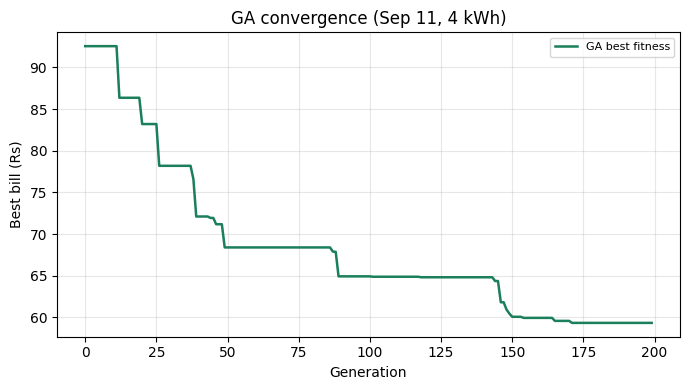

In [22]:
import matplotlib.pyplot as plt

day = get_day(df, "2026-09-11")
r = run_ga(day, capacity=4, seed=1)

plt.figure(figsize=(7, 4))
plt.plot(r["history"], color="#1a7f5a", lw=1.8, label="GA best fitness")
plt.xlabel("Generation"); plt.ylabel("Best bill (Rs)")
plt.title("GA convergence (Sep 11, 4 kWh)"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.4 Plot 2 — Optimized dispatch schedule

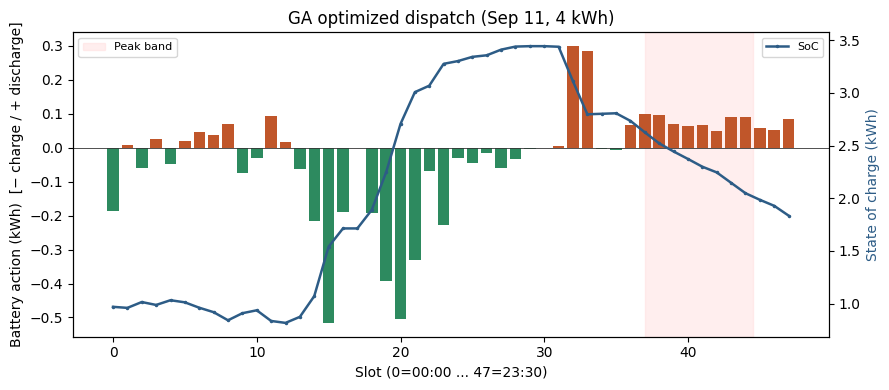

In [23]:
sch, soc = r["schedule"], r["soc"]
x = np.arange(SLOTS_PER_DAY)

fig, ax1 = plt.subplots(figsize=(9, 4))
colors = ["#2d8a5f" if a < 0 else "#c0562a" for a in sch]   # green=charge, red=discharge
ax1.bar(x, sch, color=colors, width=0.8)
ax1.axhline(0, color="#333", lw=0.6)
ax1.axvspan(37, 44.5, color="#ffdede", alpha=0.5, zorder=0, label="Peak band")
ax1.set_xlabel("Slot (0=00:00 ... 47=23:30)")
ax1.set_ylabel("Battery action (kWh)  [− charge / + discharge]")
ax1.set_title("GA optimized dispatch (Sep 11, 4 kWh)")

ax2 = ax1.twinx()
ax2.plot(x, soc, color="#2d5c86", lw=1.8, marker=".", ms=3, label="SoC")
ax2.set_ylabel("State of charge (kWh)", color="#2d5c86")
ax1.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

### 5.5 Plot 3 — Savings vs battery size

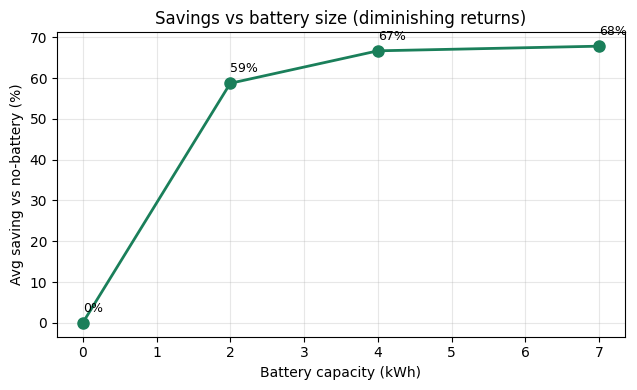

In [24]:
g = results.groupby("capacity")["saving_pct"].mean()
plt.figure(figsize=(6.5, 4))
plt.plot(g.index, g.values, "o-", color="#1a7f5a", lw=2, ms=8)
for cap, val in g.items():
    plt.annotate(f"{val:.0f}%", (cap, val), textcoords="offset points", xytext=(0, 8), fontsize=9)
plt.xlabel("Battery capacity (kWh)"); plt.ylabel("Avg saving vs no-battery (%)")
plt.title("Savings vs battery size (diminishing returns)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.6 Final results summary
Consolidate the 20-scenario sweep into headline numbers and a GA reliability check.
Reporting the spread between the mean and best bill across seeds shows the GA converges
reliably rather than by chance.

In [25]:
# GA reliability: how much do results vary across the 3 random seeds?
results["seed_spread"] = results["ga_mean"] - results["ga_best"]
active = results[results["capacity"] > 0]      # exclude 0 kWh (nothing to optimize there)

print("GA reliability (spread between mean and best bill across 3 seeds):")
print(f"  average spread : Rs {active['seed_spread'].mean():.2f}")
print(f"  maximum spread : Rs {active['seed_spread'].max():.2f}")
print("  -> a small spread confirms the GA converges reliably, not by luck\n")

print("Headline results (averaged across the 5 days):")
print(f"  no-battery baseline : Rs {results[results.capacity==0]['baseline'].mean():.1f}/day")
print(f"  7 kWh optimized     : Rs {results[results.capacity==7]['ga_best'].mean():.1f}/day")
print(f"  max saving (7 kWh)  : {results[results.capacity==7]['saving_pct'].mean():.1f}%")
print(f"  saving at 2 kWh     : {results[results.capacity==2]['saving_pct'].mean():.1f}%")
print(f"  extra gain 4->7 kWh : "
      f"{results[results.capacity==7]['saving_pct'].mean() - results[results.capacity==4]['saving_pct'].mean():.1f}% points (diminishing)")

GA reliability (spread between mean and best bill across 3 seeds):
  average spread : Rs 2.10
  maximum spread : Rs 6.90
  -> a small spread confirms the GA converges reliably, not by luck

Headline results (averaged across the 5 days):
  no-battery baseline : Rs 196.7/day
  7 kWh optimized     : Rs 60.9/day
  max saving (7 kWh)  : 67.8%
  saving at 2 kWh     : 58.7%
  extra gain 4->7 kWh : 1.1% points (diminishing)


### 5.7 Save figures
Write the three GA figures to the repo-root `figures/` folder (alongside the DP figures),
using a `ga_` prefix to mark them as heuristic outputs.

In [28]:

from pathlib import Path

# Set up the figures folder in the repository
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

day = get_day(df, "2026-09-11")
r = run_ga(day, capacity=4, seed=1)

# Figure 1: GA convergence
plt.figure(figsize=(7, 4))
plt.plot(r["history"], color="#1a7f5a", lw=1.8, label="GA best fitness")
plt.xlabel("Generation")
plt.ylabel("Best bill (Rs)")
plt.title("GA convergence (Sep 11, 4 kWh)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ga_convergence.png", dpi=150)
plt.close()

# Figure 2: Optimized battery dispatch
sch, soc = r["schedule"], r["soc"]
x = np.arange(SLOTS_PER_DAY)

fig, ax1 = plt.subplots(figsize=(9, 4))
colors = ["#2d8a5f" if a < 0 else "#c0562a" for a in sch]

ax1.bar(x, sch, color=colors, width=0.8)
ax1.axhline(0, color="#333", lw=0.6)
ax1.axvspan(37, 44.5, color="#ffdede", alpha=0.5, zorder=0, label="Peak band")
ax1.set_xlabel("Slot (0=00:00 ... 47=23:30)")
ax1.set_ylabel("Battery action (kWh)  [− charge / + discharge]")
ax1.set_title("GA optimized dispatch (Sep 11, 4 kWh)")

ax2 = ax1.twinx()
ax2.plot(x, soc, color="#2d5c86", lw=1.8, marker=".", ms=3, label="SoC")
ax2.set_ylabel("State of charge (kWh)", color="#2d5c86")

ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ga_dispatch_sep11_4kwh.png", dpi=150)
plt.close()

# Figure 3: Savings for different battery capacities
g = results.groupby("capacity")["saving_pct"].mean()

plt.figure(figsize=(6.5, 4))
plt.plot(g.index, g.values, "o-", color="#1a7f5a", lw=2, ms=8)

for cap, val in g.items():
    plt.annotate(f"{val:.0f}%", (cap, val),
                 textcoords="offset points", xytext=(0, 8), fontsize=9)

plt.xlabel("Battery capacity (kWh)")
plt.ylabel("Avg saving vs no-battery (%)")
plt.title("Savings vs battery size (diminishing returns)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ga_savings_scaling.png", dpi=150)
plt.close()

print(f"Saved 3 figures to {FIGURES_DIR}")
print("  - ga_convergence.png")
print("  - ga_dispatch_sep11_4kwh.png")
print("  - ga_savings_scaling.png")


Saved 3 figures to d:\Msc in AI\SEM-02\Optimization Methods\Assignment\WattWise\figures
  - ga_convergence.png
  - ga_dispatch_sep11_4kwh.png
  - ga_savings_scaling.png
